In [1]:
from pathlib import Path
import pandas as pd
import re
base_dir = Path('static_fits')

re_data = re.compile(r'static_fits/(3T|7T)/sub-(\d{,3})/(\d)/([a-z_]+)/all_parameters.csv')

datadict = {}

for idx, fp in enumerate(base_dir.rglob('all_parameters.csv')):
    # print(fp)
    datadict[re_data.match(str(fp)).groups()] = pd.read_csv(fp, index_col=0)['mean']
    if not idx % 100:
        print(idx)
# tmp

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800


In [2]:
df = pd.DataFrame.from_dict(datadict, orient="index")
df.index = pd.MultiIndex.from_tuples(df.index, names=["field", "subject", "block", "method"])
df = df.reorder_levels(["field", "method", "block", "subject"])
block_map = {
    '0': "0_REST",
    '1': "1_TASK",
    '2': "2_REST",
    '3': "3_TASK",
    '4': "4_REST",
}

df = df.rename(index=block_map, level="block")
df = df.sort_index()
df

Ala       Asc       Asp        Cr  \
field method     block  subject                                           
3T    basis_lw   0_REST 001      0.000000  0.986899  3.427886  4.480548   
                        002      0.000000  1.027945  3.629705  4.489934   
                        003      0.041039  1.001906  3.516588  4.408323   
                        004      0.000000  0.963709  3.420295  4.647909   
                        005      0.031705  1.020463  3.504500  4.531663   
...                                   ...       ...       ...       ...   
7T    preproc_lw 4_REST 124      0.000000  1.041755  3.603093  4.489599   
                        125      0.000000  1.051782  3.604380  4.510944   
                        126      0.000000  1.011178  3.507559  4.511823   
                        127      0.016059  1.049250  3.531342  4.525329   
                        128      0.000000  1.028128  3.631298  4.564057   

                                     GABA       GPC       GSH       Glc  \
field method     block  subject                                           
3T    basis_lw   0_REST 001      1.016854  0.504514  1.041676  0.728843   
                        002      0.916312  0.480167  1.080827  0.548259   
                        003      0.983021  0.561327  1.088367  0.554102   
                        004      1.093887  0.481546  1.087204  0.674798   
                        005      1.026520  0.515362  1.054836  0.610638   
...                                   ...       ...       ...       ...   
7T    preproc_lw 4_REST 124      1.022391  0.489835  1.060927  0.652836   
                        125      1.098562  0.503052  1.042384  0.677583   
                        126      1.069622  0.512157  1.052381  0.651662   
                        127      1.049713  0.509044  1.054876  0.645839   
                        128      1.001270  0.493854  1.073301  0.653489   

                                      Gln       Glu  ...      PEth       Tau  \
field method     block  subject                      ...                       
3T    basis_lw   0_REST 001      2.850918  8.579614  ...  1.009772  1.167199   
                        002      2.760383  8.684759  ...  1.009889  1.307052   
                        003      2.747523  8.676065  ...  0.972388  1.348341   
                        004      2.854069  8.493258  ...  1.118253  1.226932   
                        005      2.769480  8.598765  ...  0.995356  1.276196   
...                                   ...       ...  ...       ...       ...   
7T    preproc_lw 4_REST 124      2.785621  8.583567  ...  0.999846  1.209929   
                        125      2.798433  8.554441  ...  1.079202  1.194787   
                        126      2.787798  8.559243  ...  1.064656  1.254357   
                        127      2.773542  8.550602  ...  0.995247  1.242736   
                        128      2.797420  8.588379  ...  1.033492  1.224307   

                                     sIns   gamma_0    sigma_0     eps_0  \
field method     block  subject                                            
3T    basis_lw   0_REST 001      0.268565  0.724595  11.187353 -0.817988   
                        002      0.276369  0.564130  11.261632 -0.847066   
                        003      0.257409  0.638354  11.204554 -0.827890   
                        004      0.274557  0.517332  11.274481 -0.810984   
                        005      0.274962  0.869374  11.045925 -0.773920   
...                                   ...       ...        ...       ...   
7T    preproc_lw 4_REST 124      0.272277  1.719244  20.727454 -2.031928   
                        125      0.272821  1.632856  20.761095 -2.157734   
                        126      0.269488  1.625335  20.734916 -2.078234   
                        127      0.258482  1.662177  20.699883 -2.104876   
                        128      0.273322  1.629202  20.707989 -2.142600   

                                     Phi0      Phi1  B_r

Bias was calculated by evaluating the mean of the TASK blocks as a percentage change from the mean of the REST blocks on a participant by participant basis.

In [3]:
# Map each block to its condition
condition_map = {
    "0_REST": "REST",
    "1_TASK": "TASK",
    "2_REST": "REST",
    "3_TASK": "TASK",
    "4_REST": "REST",
}

df2 = df.rename(index=condition_map, level="block")

# Average over blocks, preserving the other index levels
df_mean = (
    df2
    .groupby(level=["field", "method", "block", "subject"])
    .mean()
)

df_mean

Ala       Asc       Asp        Cr  \
field method     block subject                                           
3T    basis_lw   REST  001      0.058479  0.976736  3.511740  4.525830   
                       002      0.000000  1.008021  3.538325  4.535019   
                       003      0.013680  1.012960  3.566288  4.446798   
                       004      0.002045  0.936285  3.476390  4.573978   
                       005      0.061768  1.074985  3.527907  4.488089   
...                                  ...       ...       ...       ...   
7T    preproc_lw TASK  124      0.000000  1.024228  3.592600  4.577511   
                       125      0.024743  1.027099  3.594084  4.547152   
                       126      0.015785  1.007727  3.538095  4.525741   
                       127      0.037728  0.998735  3.570437  4.572757   
                       128      0.010747  1.030659  3.616620  4.513184   

                                    GABA       GPC       GSH       Glc  \
field method     block subject                                           
3T    basis_lw   REST  001      1.011850  0.507363  1.058273  0.692130   
                       002      0.966934  0.531167  1.070119  0.593418   
                       003      1.018501  0.543870  1.067248  0.611971   
                       004      0.977358  0.491480  1.089911  0.681170   
                       005      1.004862  0.531590  1.045705  0.597489   
...                                  ...       ...       ...       ...   
7T    preproc_lw TASK  124      1.051050  0.480374  1.041247  0.698793   
                       125      1.046771  0.489631  1.061474  0.652608   
                       126      1.087828  0.503495  1.050200  0.671281   
                       127      1.022431  0.495390  1.058482  0.670275   
                       128      1.012548  0.500997  1.046695  0.671232   

                                     Gln       Glu  ...      PEth       Tau  \
field method     block subject                      ...                       
3T    basis_lw   REST  001      2.807485  8.591531  ...  1.019103  1.194209   
                       002      2.775318  8.652638  ...  0.977064  1.268823   
                       003      2.776156  8.635108  ...  0.935809  1.293253   
                       004      2.750273  8.655324  ...  1.080322  1.197781   
                       005      2.776465  8.645382  ...  0.956172  1.302200   
...                                  ...       ...  ...       ...       ...   
7T    preproc_lw TASK  124      2.776359  8.565243  ...  1.033973  1.208421   
                       125      2.780634  8.597413  ...  1.045778  1.209006   
                       126      2.777413  8.588535  ...  1.068661  1.211819   
                       127      2.807282  8.584881  ...  1.083521  1.200071   
                       128      2.752452  8.580017  ...  1.001331  1.235159   

                                    sIns   gamma_0    sigma_0     eps_0  \
field method     block subject                                            
3T    basis_lw   REST  001      0.268633  0.639709  11.207138 -0.800790   
                       002      0.274741  0.630977  11.232091 -0.809433   
                       003      0.275670  0.544548  11.251627 -0.825790   
                       004      0.267715  0.607980  11.224545 -0.766776   
                       005      0.273959  0.724494  11.163043 -0.797079   
...                                  ...       ...        ...       ...   
7T    preproc_lw TASK  124      0.263534  1.532436  20.769932 -2.165032   
                       125      0.269315  1.699504  20.711208 -2.123653   
                       126      0.265909  1.647439  20.708067 -2.065269   
                       127      0.282642  1.597872  20.750042 -2.115722   
                       128      0.265103  1.692926  20.700856 -2.102912   

                                    Phi0      Phi1  B_real_0  B_imag_0  
field method     block subject    

In [16]:
import numpy as np
rest = df_mean.xs("REST", level="block")
task = df_mean.xs("TASK", level="block")

rel_change = (task - rest).div(rest).mul(100)
rel_change = rel_change.replace([np.inf, -np.inf], np.nan)
rel_change

Ala       Asc       Asp        Cr      GABA  \
field method     subject                                                        
3T    basis_lw   001       -84.600573 -4.907877 -2.510860 -1.671416  0.246205   
                 002              NaN  0.887089 -1.606698 -1.034817  8.943040   
                 003       315.192996 -2.542564 -0.858302  0.468152 -5.844558   
                 004      1713.933046  3.639707  2.972888 -1.941200 -3.598883   
                 005      -100.000000 -0.625603 -0.882946  2.646388 -1.674012   
...                               ...       ...       ...       ...       ...   
7T    preproc_lw 124      -100.000000 -2.293229  1.195251  1.413730  0.438294   
                 125        -3.676802  0.537370 -0.184272  0.335488 -0.811410   
                 126       251.087181 -0.202955  0.064449 -0.355266  2.207303   
                 127       604.801889 -3.435160  0.187873  0.456745  0.666066   
                 128       -41.413600  1.052789  1.224734 -0.371760 -2.593593   

                               GPC       GSH       Glc       Gln       Glu  \
field method     subject                                                     
3T    basis_lw   001      6.745281  6.287656 -6.856705 -1.939839 -0.116413   
                 002     -0.490280  0.360609  7.999710 -0.579082 -0.670391   
                 003     -2.190098 -0.093727  1.970090  0.727603  0.141317   
                 004      2.719625  2.947713 -9.238334 -3.713792  0.697908   
                 005     -3.853315  1.587121 -2.111154 -1.814614  0.555274   
...                            ...       ...       ...       ...       ...   
7T    preproc_lw 124     -2.716142 -1.789381  4.070376  0.054998  0.004227   
                 125     -1.382059  0.968950 -1.082215 -0.473655 -0.040610   
                 126      1.299751 -0.643632 -0.070208 -1.337414  0.215501   
                 127      0.234143  0.063291  1.439570  0.978347  0.092887   
                 128     -0.428232 -1.391579  3.913951 -1.337716 -0.231165   

                          ...      PEth       Tau      sIns     gamma_0  \
field method     subject  ...                                             
3T    basis_lw   001      ... -1.514130  4.909634  0.610959 -100.000000   
                 002      ...  5.249954 -3.746516 -2.629009 -100.000000   
                 003      ...  4.073160 -2.666834  1.349043  -98.259629   
                 004      ... -7.229798  2.016453  1.376708 -100.000000   
                 005      ...  5.885284 -2.757512 -4.239289  -72.168301   
...                       ...       ...       ...       ...         ...   
7T    preproc_lw 124      ...  0.842033 -0.839841 -2.097942   -7.046936   
                 125      ... -1.241468 -0.721658 -1.345961    5.111890   
                 126      ...  3.164910 -1.728465 -2.053854    1.222759   
                 127      ...  3.864191 -2.702572  6.264921   -1.597404   
                 128      ... -3.189159  0.598178 -2.198123    2.667283   

                           sigma_0     eps_0       Phi0       Phi1  B_real_0  \
field method     subject                                                       
3T    basis_lw   001      0.258170  1.898120  11.314815   2.170980       NaN   
                 002      0.013214  3.506340  21.423369  -8.394539       NaN   
                 003     -0.157809 -1.019635  -7.727261 -19.063423       NaN   
                 004      0.206019  7.804598 -23.407490 -19.251622       NaN   
                 005     -0.009671 -1.231945   9.780886  22.784652       NaN   
...                            ...       ...        ...        ...       ...   
7T    preproc_lw 124      0.179893  4.222786 -20.107392 -22.939498       NaN   
                 125     -0.077243 -0.718493   9.569213  11.892828       NaN   
                 126     -0.012772 -1.103493   7.677893  18.222373       NaN   
                 127      0.105803  0.641587  -1.478488   0.113247       NaN   
                 128      0.0

In [17]:
keep = [
    "Asc", "Asp", "GABA", "Glc", "Gln", "Glu", "GSH", "Ins",
    "Lac", "PEth", "sIns", "Tau", "tCho", "tCr", "tNAA",
]

rel_change_sub = rel_change.copy()

rel_change_sub = rel_change_sub.assign(
    tNAA=rel_change_sub["NAA"] + rel_change_sub["NAAG"],
    tCho=rel_change_sub["GPC"] + rel_change_sub["PCh"],
    tCr=rel_change_sub["Cr"] + rel_change_sub["PCr"],
)

rel_change_sub = rel_change_sub.loc[:, keep]

In [18]:
# Summary statistics across subjects
mean = rel_change_sub.groupby(level=["field", "method"]).mean()
sd = rel_change_sub.groupby(level=["field", "method"]).std()

# Cohen's d (one-sample effect size against 0)
cohens_d = mean / sd

summary = pd.concat(
    {
        "Mean": mean,
        "SD": sd,
        "Cohens d": cohens_d,
    },
    names=["value_type"],
)

summary = summary.reorder_levels(["field", "method", "value_type"]).sort_index()
summary

Asc       Asp      GABA       Glc       Gln  \
field method     value_type                                                     
3T    basis_lw   Cohens d    0.038844 -0.052728 -0.140876 -0.138003 -0.228789   
                 Mean        0.198683 -0.093711 -0.731426 -0.883464 -0.421189   
                 SD          5.114914  1.777254  5.191992  6.401783  1.840948   
      default    Cohens d    0.011027  0.071467  0.094937 -0.023700 -0.083124   
                 Mean        0.056282  0.130231  0.506451 -0.151381 -0.152276   
                 SD          5.104215  1.822260  5.334582  6.387381  1.831912   
      preproc_lw Cohens d    0.039822  0.064205  0.022531 -0.054785 -0.060311   
                 Mean        0.214467  0.126067  0.126637 -0.363408 -0.114466   
                 SD          5.385583  1.963502  5.620635  6.633394  1.897929   
7T    basis_lw   Cohens d    0.534733 -0.776794 -1.245555 -1.048877 -0.592224   
                 Mean        1.197820 -0.726530 -2.986289 -3.483393 -0.487922   
                 SD          2.240033  0.935293  2.397556  3.321069  0.823880   
      default    Cohens d    0.079752  0.071040 -0.043575 -0.035004 -0.266921   
                 Mean        0.179110  0.067227 -0.108513 -0.122528 -0.220382   
                 SD          2.245841  0.946331  2.490267  3.500453  0.825646   
      preproc_lw Cohens d   -0.021805  0.202101  0.077077  0.058690 -0.202933   
                 Mean       -0.058137  0.213305  0.213904  0.241614 -0.187203   
                 SD          2.666232  1.055438  2.775187  4.116785  0.922489   

                                  Glu       GSH       Ins       Lac      PEth  \
field method     value_type                                                     
3T    basis_lw   Cohens d    0.249223  0.104531  0.042941  0.083859  0.078322   
                 Mean        0.207561  0.288781  0.024042  0.489047  0.420470   
                 SD          0.832832  2.762625  0.559897  5.831739  5.368511   
      default    Cohens d    0.039809  0.070047 -0.036922  0.082169  0.156372   
                 Mean        0.033680  0.193505 -0.020315  0.478743  0.836145   
                 SD          0.846037  2.762499  0.550210  5.826292  5.347140   
      preproc_lw Cohens d    0.103451  0.070066 -0.008963  0.023957  0.076136   
                 Mean        0.091205  0.202887 -0.005018  0.148506  0.433405   
                 SD          0.881622  2.895655  0.559898  6.198902  5.692529   
7T    basis_lw   Cohens d    1.462123  0.223368  0.990195  0.218648 -0.701444   
                 Mean        0.386334  0.228538  0.204117  0.412733 -1.974746   
                 SD          0.264228  1.023145  0.206138  1.887661  2.815259   
      default    Cohens d   -0.064901  0.047470 -0.117159  0.095877  0.146495   
                 Mean       -0.017688  0.048646 -0.025227  0.181324  0.422105   
                 SD          0.272537  1.024772  0.215326  1.891222  2.881358   
      preproc_lw Cohens d   -0.111829  0.083669 -0.127421 -0.023082  0.192543   
                 Mean       -0.034962  0.090481 -0.030440 -0.046508  0.626394   
                 SD          0.312640  1.081420  0.238891  2.014890  3.253264   

                                 sIns       Tau      tCho       tCr      tNAA  
field method     value_type                                                    
3T    basis_lw   Cohens d    0.044614  0.019124  0.158879  0.182670  0.249944  
                 Mean        0.173724  0.070157  0.334733  0.180350  0.483722  
                 SD          3.893954  3.668471  2.106845  0.987301  1.935319  
      default    Cohens d    0.070287 -0.026757  0.039365 -0.090405  0.057327  
                 Mean        0.273066 -0.097447  0.083772 -0.094072  0.112517  
                 SD          3.885009  3.641935  2.128106  1.040559  1.962734  
      preproc_lw Cohens d    0.030037  0.062173  0.041898 -0.044622  0.136053  
                 Mean        0.122454  0.247262  0.091796 -0.051025  0.2

In [19]:
long_df = (
    summary
    .stack()
    .rename("value")
    .reset_index()
)
long_df = long_df.rename(columns={"level_3": "Metabolite"})
long_df

,field,method,value_type,Metabolite,value
0,3T,basis_lw,Cohens d,Asc,0.038844
1,3T,basis_lw,Cohens d,Asp,-0.052728
2,3T,basis_lw,Cohens d,GABA,-0.140876
3,3T,basis_lw,Cohens d,Glc,-0.138003
4,3T,basis_lw,Cohens d,Gln,-0.228789
...,...,...,...,...,...
265,7T,preproc_lw,SD,sIns,1.989117
266,7T,preproc_lw,SD,Tau,1.428586
267,7T,preproc_lw,SD,tCho,0.987960
268,7T,preproc_lw,SD,tCr,0.557780


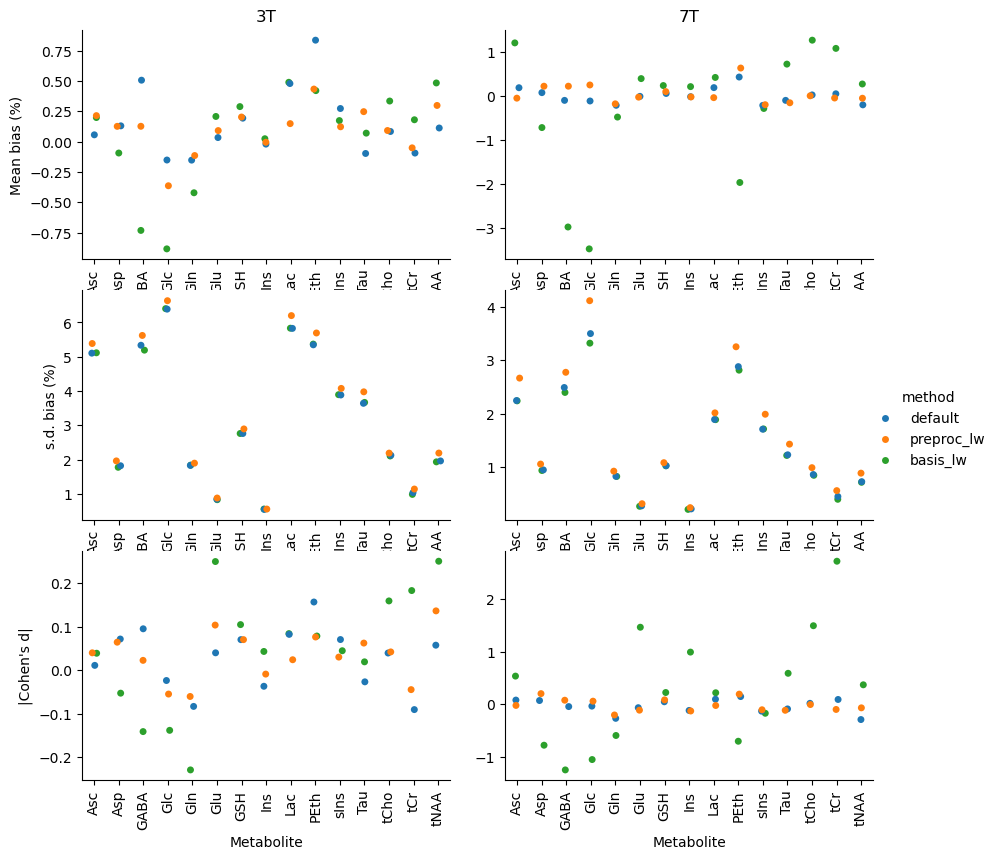

In [21]:
import matplotlib.colors  # important: force submodule registration
import seaborn as sns

effect_plot2 = sns.catplot(
    data=long_df,
    kind="strip",
    x="Metabolite",
    hue="method",
    y="value",
    col="field",
    row="value_type",
    col_order=["3T", "7T"],
    row_order=["Mean", "SD", "Cohens d"],
    sharey=False,
    sharex=False,
    hue_order=["default", "preproc_lw", "basis_lw"],
    order=[
        "Asc", "Asp", "GABA", "Glc", "Gln", "Glu", "GSH", "Ins",
        "Lac", "PEth", "sIns", "Tau", "tCho", "tCr", "tNAA",
    ],
)

_=effect_plot2.set_xticklabels(rotation=90)
effect_plot2.figure.set_size_inches(10,8)

_ = effect_plot2.axes.flat[0].set(ylabel="Mean bias (%)")
_ = effect_plot2.axes.flat[2].set(ylabel="s.d. bias (%)")
_ = effect_plot2.axes.flat[4].set(ylabel="|Cohen's d|")

for ax in effect_plot2.axes.flat[2:]:
    ax.set(title="")
_ = effect_plot2.axes.flat[0].set(title="3T")
_ = effect_plot2.axes.flat[1].set(title="7T")

effect_plot2.savefig("figures/static_effect_size_per_met.png", dpi=600, bbox_inches="tight") 